In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split,cross_val_score, KFold ,GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor


In [44]:
#Load the dataset
DATA_DIR = '../data/raw/'

df = pd.read_csv(os.path.join(DATA_DIR, 'sales.csv'), parse_dates=['Date'])
promo = pd.read_csv(os.path.join(DATA_DIR, 'promotions.csv'), parse_dates=['start_date', 'end_date'])

df

,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79
...,...,...,...
3828,2022-12-27,2100553.66,2184872.24
3829,2022-12-28,3448729.20,3513621.00
3830,2022-12-29,3083944.33,3170787.10
3831,2022-12-30,2884668.76,3022292.15


In [45]:
promo['start_date'] = pd.to_datetime(promo['start_date'])
promo['end_date'] = pd.to_datetime(promo['end_date'])
promo

,promo_id,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
0,PROMO-0001,Spring Sale 2013,percentage,12.0,2013-03-18,2013-04-17,NaN,email,1,0
1,PROMO-0002,Mid-Year Sale 2013,percentage,18.0,2013-06-23,2013-07-22,NaN,online,0,0
2,PROMO-0003,Fall Launch 2013,percentage,10.0,2013-08-30,2013-10-02,NaN,email,0,0
3,PROMO-0004,Year-End Sale 2013,percentage,20.0,2013-11-18,2014-01-02,NaN,all_channels,0,50000
4,PROMO-0005,Urban Blowout 2013,fixed,50.0,2013-07-30,2013-09-02,Streetwear,online,0,150000
5,PROMO-0006,Rural Special 2013,percentage,15.0,2013-01-31,2013-03-01,Outdoor,in_store,0,0
6,PROMO-0007,Spring Sale 2014,percentage,12.0,2014-03-18,2014-04-17,NaN,email,1,0
7,PROMO-0008,Mid-Year Sale 2014,percentage,18.0,2014-06-23,2014-07-22,NaN,social_media,0,0
8,PROMO-0009,Fall Launch 2014,percentage,10.0,2014-08-30,2014-10-01,NaN,all_channels,0,100000
9,PROMO-0010,Year-End Sale 2014,percentage,20.0,2014-11-19,2015-01-02,NaN,all_channels,0,100000


In [46]:
import pandas as pd
import numpy as np

start_date = '2012-07-04'
end_date = '2022-12-31'

def create_promotion_features(promo, start_date, end_date):

    date_range = pd.date_range(start=start_date, end=end_date, freq='D')
    daily = pd.DataFrame({'Date': date_range})
    
    active_promos = []
    for idx, row in promo.iterrows():
        start = pd.to_datetime(row['start_date'])
        end = pd.to_datetime(row['end_date'])
        
        mask = (daily['Date'] >= start) & (daily['Date'] <= end)
        active_dates = daily.loc[mask, 'Date']
        
        for d in active_dates:
            active_promos.append({
                'Date': d,
                'promo_id': row['promo_id'],
                'promo_type': row['promo_type'],
                'discount_value': row['discount_value'],
                'stackable_flag': row['stackable_flag'],
                'applicable_category': row['applicable_category'],
                'promo_channel': row['promo_channel'],
                'min_order_value': row['min_order_value']
            })
    
    if not active_promos:
        daily = daily.set_index('Date')
        daily['num_active_promos'] = 0
        daily['num_promo_percentage'] = 0
        daily['num_promo_fixed'] = 0
        daily['avg_discount_value'] = 0
        daily['has_stackable'] = 0
        daily['num_specific_category_promos'] = 0
        daily = daily.reset_index()
        return daily
    
    active_df = pd.DataFrame(active_promos)
    num_active = active_df.groupby('Date')['promo_id'].nunique().rename('num_active_promos')
    
    promo_type_counts = active_df.groupby(['Date', 'promo_type']).size().unstack(fill_value=0)
    for col in ['percentage', 'fixed']:
        if col not in promo_type_counts.columns:
            promo_type_counts[col] = 0
    promo_type_counts.columns = ['num_promo_' + str(c) for c in promo_type_counts.columns]
    
    avg_discount = active_df.groupby('Date')['discount_value'].mean().rename('avg_discount_value')

    has_stackable = active_df.groupby('Date')['stackable_flag'].max().rename('has_stackable')

    specific_cat = active_df.groupby('Date')['applicable_category'].apply(
        lambda x: x.notna().sum()
    ).rename('num_specific_category_promos')

    min_order_stats = active_df.groupby('Date')['min_order_value'].agg(['min', 'max', 'mean'])
    min_order_stats.columns = ['min_order_value_min', 'min_order_value_max', 'min_order_value_mean']

    channel_dummies = pd.get_dummies(active_df[['Date', 'promo_channel']], columns=['promo_channel'], prefix='channel')

    channel_cols = [c for c in channel_dummies.columns if c.startswith('channel_')]
    channel_daily = channel_dummies.groupby('Date')[channel_cols].sum()

    daily = daily.set_index('Date')
    daily = daily.join(num_active, how='left')
    daily = daily.join(promo_type_counts, how='left')
    daily = daily.join(avg_discount, how='left')
    daily = daily.join(has_stackable, how='left')
    daily = daily.join(specific_cat, how='left')
    daily = daily.join(channel_daily, how='left')
    daily = daily.join(min_order_stats, how='left')

    daily = daily.fillna(0)
    daily = daily.reset_index()
    
    return daily
daily = create_promotion_features(promo, start_date, end_date)
daily

,Date,num_active_promos,num_promo_fixed,num_promo_percentage,avg_discount_value,has_stackable,num_specific_category_promos,channel_all_channels,channel_email,channel_in_store,channel_online,channel_social_media,min_order_value_min,min_order_value_max,min_order_value_mean
0,2012-07-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2012-07-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2012-07-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2012-07-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2012-07-08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3828,2022-12-27,1.0,0.0,1.0,20.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,50000.0,50000.0,50000.0
3829,2022-12-28,1.0,0.0,1.0,20.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,50000.0,50000.0,50000.0
3830,2022-12-29,1.0,0.0,1.0,20.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,50000.0,50000.0,50000.0
3831,2022-12-30,1.0,0.0,1.0,20.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,50000.0,50000.0,50000.0


In [47]:

def generate_future_promos(start_year=2023, end_year=2024):
    future_promos = []
    patterns = [
        ('Spring Sale', 'percentage', 12, 3, 18, 4, 17, None, 'all_channels', 1, 50000),
        ('Mid-Year Sale', 'percentage', 18, 6, 23, 7, 22, None, 'online', 0, 0),
        ('Fall Launch', 'percentage', 10, 8, 30, 10, 1, None, 'all_channels', 0, 100000),
        ('Year-End Sale', 'percentage', 20, 11, 18, 1, 2, None, 'all_channels', 0, 50000),
        ('Urban Blowout', 'fixed', 50, 7, 30, 9, 2, 'Streetwear', 'online', 0, 150000),
        ('Rural Special', 'percentage', 15, 1, 30, 3, 1, 'Outdoor', 'in_store', 0, 0),
    ]
    for year in range(start_year, end_year + 1):
        for i, (name, ptype, discount, sm, sd, em, ed, cat, channel, stackable, min_order) in enumerate(patterns):
            end_year_adj = year + 1 if (em == 1 and ed == 2) else year
            future_promos.append({
                'promo_id': f'FUTURE-{year}-{i+1:03d}',
                'promo_name': f'{name} {year}',
                'promo_type': ptype,
                'discount_value': discount,
                'start_date': pd.Timestamp(year=year, month=sm, day=sd),
                'end_date': pd.Timestamp(year=end_year_adj, month=em, day=ed),
                'applicable_category': cat,
                'promo_channel': channel,
                'stackable_flag': stackable,
                'min_order_value': min_order
            })
    return pd.DataFrame(future_promos)

future_promo = generate_future_promos(2023, 2024)
promo_all = pd.concat([promo, future_promo], ignore_index=True)

all_promo_features = create_promotion_features(promo_all, '2012-07-04', '2024-07-01')
print(f"Promo features shape: {all_promo_features.shape}")

Promo features shape: (4381, 15)


In [48]:
data = df.merge(daily, left_on='Date', right_on='Date', how='left')

promo_cols = [c for c in daily.columns if c != 'Date']
for col in promo_cols:
    if col in data.columns:
        data[col] = data[col].fillna(0)

print(f"Data shape: {data.shape}")
print(f"Các cột: {data.columns.tolist()}")

Data shape: (3833, 17)
Các cột: ['Date', 'Revenue', 'COGS', 'num_active_promos', 'num_promo_fixed', 'num_promo_percentage', 'avg_discount_value', 'has_stackable', 'num_specific_category_promos', 'channel_all_channels', 'channel_email', 'channel_in_store', 'channel_online', 'channel_social_media', 'min_order_value_min', 'min_order_value_max', 'min_order_value_mean']


In [49]:
data['year'] = data['Date'].dt.year
data['month'] = data['Date'].dt.month
data['day'] = data['Date'].dt.day
data['dayofweek'] = data['Date'].dt.dayofweek
data['is_weekend'] = data['dayofweek'].isin([5, 6]).astype(int)
holidays_and_sales = ['01-01', '02-14', '03-08', '04-30', '05-01', '09-02', '10-20', '11-11', '12-12', '12-24']
data['is_holiday'] = data['Date'].dt.strftime('%m-%d').isin(holidays_and_sales).astype(int)
data['dayofyear'] = data['Date'].dt.dayofyear
data['dayofyearsin'] = np.sin(2 * np.pi * data['dayofyear'] / 365.25)
data['dayofyearcos'] = np.cos(2 * np.pi * data['dayofyear'] / 365.25)
data['weekofyear'] = data['Date'].dt.isocalendar().week.astype(int)
data

,Date,Revenue,COGS,num_active_promos,num_promo_fixed,num_promo_percentage,avg_discount_value,has_stackable,num_specific_category_promos,channel_all_channels,...,year,month,day,dayofweek,is_weekend,is_holiday,dayofyear,dayofyearsin,dayofyearcos,weekofyear
0,2012-07-04,5123547.94,3982991.19,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2012,7,4,2,0,0,186,-0.058026,-0.998315,27
1,2012-07-05,2751773.45,2150580.23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2012,7,5,3,0,0,187,-0.075190,-0.997169,27
2,2012-07-06,3054029.42,2517632.84,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2012,7,6,4,0,0,188,-0.092331,-0.995728,27
3,2012-07-07,2667930.94,2108246.62,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2012,7,7,5,1,0,189,-0.109446,-0.993993,27
4,2012-07-08,2360851.90,1808622.79,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2012,7,8,6,1,0,190,-0.126528,-0.991963,27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3828,2022-12-27,2100553.66,2184872.24,1.0,0.0,1.0,20.0,0.0,0.0,1.0,...,2022,12,27,1,0,0,361,-0.073045,0.997329,52
3829,2022-12-28,3448729.20,3513621.00,1.0,0.0,1.0,20.0,0.0,0.0,1.0,...,2022,12,28,2,0,0,362,-0.055879,0.998438,52
3830,2022-12-29,3083944.33,3170787.10,1.0,0.0,1.0,20.0,0.0,0.0,1.0,...,2022,12,29,3,0,0,363,-0.038696,0.999251,52
3831,2022-12-30,2884668.76,3022292.15,1.0,0.0,1.0,20.0,0.0,0.0,1.0,...,2022,12,30,4,0,0,364,-0.021501,0.999769,52


In [50]:
lags = [1, 2, 3, 7, 14, 30, 60, 90, 365]
windows = [7, 14, 30]

for lag in lags:
    data[f'Revenue_lag_{lag}'] = data['Revenue'].shift(lag)
    data[f'COGS_lag_{lag}'] = data['COGS'].shift(lag)

for w in windows:
    data[f'Revenue_roll_mean_{w}'] = data['Revenue'].shift(1).rolling(w).mean()
    data[f'Revenue_roll_std_{w}'] = data['Revenue'].shift(1).rolling(w).std()
    data[f'COGS_roll_mean_{w}'] = data['COGS'].shift(1).rolling(w).mean()
    data[f'COGS_roll_std_{w}'] = data['COGS'].shift(1).rolling(w).std()
data['Gross_Margin_lag_1'] = (data['Revenue'].shift(1) - data['COGS'].shift(1)) / (data['Revenue'].shift(1) + 1)
data = data.dropna().reset_index(drop=True)
data

,Date,Revenue,COGS,num_active_promos,num_promo_fixed,num_promo_percentage,avg_discount_value,has_stackable,num_specific_category_promos,channel_all_channels,...,COGS_roll_std_7,Revenue_roll_mean_14,Revenue_roll_std_14,COGS_roll_mean_14,COGS_roll_std_14,Revenue_roll_mean_30,Revenue_roll_std_30,COGS_roll_mean_30,COGS_roll_std_30,Gross_Margin_lag_1
0,2013-07-04,2521315.44,2408274.98,1.0,0.0,1.0,18.0,0.0,0.0,0.0,...,1.054955e+06,6.922596e+06,1.320188e+06,6.355767e+06,1.532435e+06,6.182359e+06,1.431961e+06,5.329885e+06,1.595644e+06,0.021058
1,2013-07-05,2494107.65,2432073.97,1.0,0.0,1.0,18.0,0.0,0.0,0.0,...,2.105383e+06,6.597072e+06,1.765504e+06,6.133809e+06,1.854638e+06,6.086493e+06,1.575415e+06,5.266915e+06,1.673187e+06,0.044834
2,2013-07-06,2452372.43,2331799.51,1.0,0.0,1.0,18.0,0.0,0.0,0.0,...,2.626662e+06,6.380483e+06,2.067183e+06,5.993476e+06,2.059231e+06,5.940931e+06,1.698335e+06,5.164478e+06,1.750388e+06,0.024872
3,2013-07-07,2958215.01,2950992.63,1.0,0.0,1.0,18.0,0.0,0.0,0.0,...,2.534362e+06,6.190133e+06,2.301826e+06,5.866368e+06,2.232017e+06,5.832914e+06,1.813782e+06,5.087798e+06,1.823375e+06,0.049166
4,2013-07-08,2571901.18,2450996.77,1.0,0.0,1.0,18.0,0.0,0.0,0.0,...,2.450782e+06,5.983965e+06,2.459050e+06,5.730350e+06,2.353112e+06,5.803404e+06,1.854021e+06,5.086602e+06,1.824812e+06,0.002441
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3463,2022-12-27,2100553.66,2184872.24,1.0,0.0,1.0,20.0,0.0,0.0,1.0,...,3.592945e+05,1.699922e+06,3.454986e+05,1.727411e+06,3.540577e+05,1.589132e+06,5.656207e+05,1.626506e+06,5.938495e+05,-0.023751
3464,2022-12-28,3448729.20,3513621.00,1.0,0.0,1.0,20.0,0.0,0.0,1.0,...,3.838777e+05,1.731940e+06,3.611613e+05,1.762933e+06,3.741305e+05,1.554530e+06,4.948911e+05,1.589892e+06,5.170779e+05,-0.040141
3465,2022-12-29,3083944.33,3170787.10,1.0,0.0,1.0,20.0,0.0,0.0,1.0,...,7.856147e+05,1.859546e+06,5.824504e+05,1.893320e+06,5.974926e+05,1.599323e+06,5.967576e+05,1.635268e+06,6.180152e+05,-0.018816
3466,2022-12-30,2884668.76,3022292.15,1.0,0.0,1.0,20.0,0.0,0.0,1.0,...,9.005524e+05,1.973090e+06,6.560662e+05,2.008776e+06,6.777455e+05,1.616831e+06,6.325077e+05,1.651148e+06,6.513871e+05,-0.028160


In [51]:
current_features = [
    'year', 'month', 'day', 'dayofweek', 'is_weekend', 'is_holiday',
    'dayofyear', 'dayofyearsin', 'dayofyearcos', 'weekofyear',
    'num_active_promos', 'num_promo_percentage', 'num_promo_fixed',
    'avg_discount_value', 'has_stackable', 'num_specific_category_promos',
    'min_order_value_mean',
    'channel_all_channels', 'channel_email', 'channel_in_store', 'channel_online', 'channel_social_media'
]
lag_features_cogs = [f'COGS_lag_{lag}' for lag in lags]
lag_features_revenue = [f'Revenue_lag_{lag}' for lag in lags]
roll_features_cogs = [f'COGS_roll_mean_{w}' for w in windows] + [f'COGS_roll_std_{w}' for w in windows]
roll_features_revenue = [f'Revenue_roll_mean_{w}' for w in windows] + [f'Revenue_roll_std_{w}' for w in windows]
features_for_cogs = current_features + lag_features_cogs + roll_features_cogs
features_for_revenue = current_features + lag_features_revenue + lag_features_cogs + roll_features_revenue + roll_features_cogs + ['Gross_Margin_lag_1']
print(f"Features COGS: {len(features_for_cogs)}")
print(f"Features Revenue: {len(features_for_revenue)}")

Features COGS: 37
Features Revenue: 53


In [52]:
train_mask = data['Date'] < '2022-01-01'
val_mask = (data['Date'] >= '2022-01-01') & (data['Date'] <= '2022-12-31')

X_train_revenue = data.loc[train_mask, features_for_revenue]
y_train_revenue = data.loc[train_mask, 'Revenue']
X_val_revenue = data.loc[val_mask, features_for_revenue]
y_val_revenue = data.loc[val_mask, 'Revenue']

X_train_cogs = data.loc[train_mask, features_for_cogs]
y_train_cogs = data.loc[train_mask, 'COGS']
X_val_cogs = data.loc[val_mask, features_for_cogs]
y_val_cogs = data.loc[val_mask, 'COGS']

print(f"\nTrain: {len(X_train_revenue)} ngày, Validation: {len(X_val_revenue)} ngày")


Train: 3103 ngày, Validation: 365 ngày


In [53]:
model_lgb_rev = LGBMRegressor(n_estimators=2000, learning_rate=0.02, num_leaves=64,subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1)
model_xgb_rev = xgb.XGBRegressor(n_estimators=2000, learning_rate=0.02, max_depth=6,subsample=0.8, colsample_bytree=0.8, random_state=42, tree_method="hist", verbosity=0)
model_cat_rev = CatBoostRegressor(loss_function='RMSE', iterations=1000, learning_rate=0.1, depth=6, random_seed=42, verbose=0)

model_lgb_rev.fit(X_train_revenue, y_train_revenue)
model_xgb_rev.fit(X_train_revenue, y_train_revenue)
model_cat_rev.fit(X_train_revenue, y_train_revenue)

oof_lgb_rev = model_lgb_rev.predict(X_val_revenue)
oof_xgb_rev = model_xgb_rev.predict(X_val_revenue)
oof_cat_rev = model_cat_rev.predict(X_val_revenue)

oof_blend_rev = 0.4 * oof_lgb_rev + 0.35 * oof_cat_rev + 0.25 * oof_xgb_rev

print(f"LightGBM - MAE: {mean_absolute_error(y_val_revenue, oof_lgb_rev):,.0f}, RMSE: {np.sqrt(mean_squared_error(y_val_revenue, oof_lgb_rev)):,.0f}, R²: {r2_score(y_val_revenue, oof_lgb_rev):.4f}")
print(f"XGBoost - MAE: {mean_absolute_error(y_val_revenue, oof_xgb_rev):,.0f}, RMSE: {np.sqrt(mean_squared_error(y_val_revenue, oof_xgb_rev)):,.0f}, R²: {r2_score(y_val_revenue, oof_xgb_rev):.4f}")
print(f"CatBoost - MAE: {mean_absolute_error(y_val_revenue, oof_cat_rev):,.0f}, RMSE: {np.sqrt(mean_squared_error(y_val_revenue, oof_cat_rev)):,.0f}, R²: {r2_score(y_val_revenue, oof_cat_rev):.4f}")
print(f"Blend - MAE: {mean_absolute_error(y_val_revenue, oof_blend_rev):,.0f}, RMSE: {np.sqrt(mean_squared_error(y_val_revenue, oof_blend_rev)):,.0f}, R²: {r2_score(y_val_revenue, oof_blend_rev):.4f}")

LightGBM - MAE: 578,303, RMSE: 785,936, R²: 0.7795
XGBoost - MAE: 557,878, RMSE: 764,398, R²: 0.7914
CatBoost - MAE: 550,522, RMSE: 764,222, R²: 0.7915
Blend - MAE: 556,687, RMSE: 762,799, R²: 0.7923


In [54]:
stack_train_rev = np.vstack([oof_lgb_rev, oof_cat_rev, oof_xgb_rev]).T
lvl2_rev = Ridge(alpha=1.0)
lvl2_rev.fit(stack_train_rev, y_val_revenue)
pred_stack_rev = lvl2_rev.predict(stack_train_rev)

print(f"Stacked Ridge - MAE: {mean_absolute_error(y_val_revenue, pred_stack_rev):,.0f}, RMSE: {np.sqrt(mean_squared_error(y_val_revenue, pred_stack_rev)):,.0f}, R²: {r2_score(y_val_revenue, pred_stack_rev):.6f}")
print(f"Ridge coefs: {lvl2_rev.coef_}")

Stacked Ridge - MAE: 542,734, RMSE: 746,915, R²: 0.800873
Ridge coefs: [-0.19488363  0.45395032  0.70570708]


In [55]:
model_lgb_cogs = LGBMRegressor(n_estimators=2000, learning_rate=0.02, num_leaves=64,subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1)
model_xgb_cogs = xgb.XGBRegressor(n_estimators=2000, learning_rate=0.02, max_depth=6,subsample=0.8, colsample_bytree=0.8, random_state=42, tree_method="hist", verbosity=0)
model_cat_cogs = CatBoostRegressor(loss_function='RMSE', iterations=1000, learning_rate=0.1,depth=6, random_seed=42, verbose=0)

model_lgb_cogs.fit(X_train_cogs, y_train_cogs)
model_xgb_cogs.fit(X_train_cogs, y_train_cogs)
model_cat_cogs.fit(X_train_cogs, y_train_cogs)

oof_lgb_cogs = model_lgb_cogs.predict(X_val_cogs)
oof_xgb_cogs = model_xgb_cogs.predict(X_val_cogs)
oof_cat_cogs = model_cat_cogs.predict(X_val_cogs)

oof_blend_cogs = 0.4 * oof_lgb_cogs + 0.35 * oof_cat_cogs + 0.25 * oof_xgb_cogs

print(f"LightGBM - MAE: {mean_absolute_error(y_val_cogs, oof_lgb_cogs):,.0f}, RMSE: {np.sqrt(mean_squared_error(y_val_cogs, oof_lgb_cogs)):,.0f}, R²: {r2_score(y_val_cogs, oof_lgb_cogs):.4f}")
print(f"XGBoost  - MAE: {mean_absolute_error(y_val_cogs, oof_xgb_cogs):,.0f}, RMSE: {np.sqrt(mean_squared_error(y_val_cogs, oof_xgb_cogs)):,.0f}, R²: {r2_score(y_val_cogs, oof_xgb_cogs):.4f}")
print(f"CatBoost - MAE: {mean_absolute_error(y_val_cogs, oof_cat_cogs):,.0f}, RMSE: {np.sqrt(mean_squared_error(y_val_cogs, oof_cat_cogs)):,.0f}, R²: {r2_score(y_val_cogs, oof_cat_cogs):.4f}")
print(f"Blend    - MAE: {mean_absolute_error(y_val_cogs, oof_blend_cogs):,.0f}, RMSE: {np.sqrt(mean_squared_error(y_val_cogs, oof_blend_cogs)):,.0f}, R²: {r2_score(y_val_cogs, oof_blend_cogs):.4f}")

stack_train_cogs = np.vstack([oof_lgb_cogs, oof_cat_cogs, oof_xgb_cogs]).T
lvl2_cogs = Lasso(alpha=0.1, max_iter=5000)
lvl2_cogs.fit(stack_train_cogs, y_val_cogs)
pred_stack_cogs = lvl2_cogs.predict(stack_train_cogs)

print(f"Stacked Lasso - MAE: {mean_absolute_error(y_val_cogs, pred_stack_cogs):,.0f}, RMSE: {np.sqrt(mean_squared_error(y_val_cogs, pred_stack_cogs)):,.0f}, R²: {r2_score(y_val_cogs, pred_stack_cogs):.4f}")
print(f"Lasso coefs: {lvl2_cogs.coef_}")

LightGBM - MAE: 503,473, RMSE: 674,423, R²: 0.7862
XGBoost  - MAE: 486,133, RMSE: 661,846, R²: 0.7941
CatBoost - MAE: 472,543, RMSE: 638,851, R²: 0.8082
Blend    - MAE: 479,900, RMSE: 648,328, R²: 0.8024
Stacked Lasso - MAE: 467,531, RMSE: 628,979, R²: 0.8140
Lasso coefs: [-0.16675059  0.83993619  0.28735014]


In [56]:
from prophet import Prophet

prophet_train_cogs = data.loc[train_mask, ['Date', 'COGS']].rename(columns={'Date': 'ds', 'COGS': 'y'})
model_prophet_cogs = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model_prophet_cogs.fit(prophet_train_cogs)

prophet_train_rev = data.loc[train_mask, ['Date', 'Revenue']].rename(columns={'Date': 'ds', 'Revenue': 'y'})
model_prophet_rev = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model_prophet_rev.fit(prophet_train_rev)

11:34:28 - cmdstanpy - INFO - Chain [1] start processing
11:34:29 - cmdstanpy - INFO - Chain [1] done processing
11:34:30 - cmdstanpy - INFO - Chain [1] start processing
11:34:30 - cmdstanpy - INFO - Chain [1] done processing


In [57]:
prophet_pred_rev_train = model_prophet_rev.predict(pd.DataFrame({'ds': data.loc[train_mask, 'Date']}))['yhat'].values

residuals_rev_train = data.loc[train_mask, 'Revenue'].values - prophet_pred_rev_train

model_lgb_rev.fit(X_train_revenue, residuals_rev_train)
model_xgb_rev.fit(X_train_revenue, residuals_rev_train)
model_cat_rev.fit(X_train_revenue, residuals_rev_train)

oof_lgb_rev_res = model_lgb_rev.predict(X_val_revenue)
oof_xgb_rev_res = model_xgb_rev.predict(X_val_revenue)
oof_cat_rev_res = model_cat_rev.predict(X_val_revenue)

stack_train_rev_res = np.vstack([oof_lgb_rev_res, oof_cat_rev_res, oof_xgb_rev_res]).T
y_val_rev_res = data.loc[val_mask, 'Revenue'].values - model_prophet_rev.predict(pd.DataFrame({'ds': data.loc[val_mask, 'Date']}))['yhat'].values

lvl2_rev = Lasso(alpha=0.1, max_iter=5000)
lvl2_rev.fit(stack_train_rev_res, y_val_rev_res)
print(f"Revenue Lasso coefs: {lvl2_rev.coef_}")

pred_stack_rev_res = lvl2_rev.predict(stack_train_rev_res)
pred_rev_final = model_prophet_rev.predict(pd.DataFrame({'ds': data.loc[val_mask, 'Date']}))['yhat'].values + pred_stack_rev_res
print(f"Revenue Final (Prophet + Stacked Residuals) - R²: {r2_score(y_val_revenue, pred_rev_final):.4f}")

Revenue Lasso coefs: [0.20522659 0.54954231 0.32381455]
Revenue Final (Prophet + Stacked Residuals) - R²: 0.7959


In [58]:

prophet_pred_cogs_train = model_prophet_cogs.predict(pd.DataFrame({'ds': data.loc[train_mask, 'Date']}))['yhat'].values

residuals_cogs_train = data.loc[train_mask, 'COGS'].values - prophet_pred_cogs_train

model_lgb_cogs.fit(X_train_cogs, residuals_cogs_train)
model_xgb_cogs.fit(X_train_cogs, residuals_cogs_train)
model_cat_cogs.fit(X_train_cogs, residuals_cogs_train)

oof_lgb_cogs_res = model_lgb_cogs.predict(X_val_cogs)
oof_xgb_cogs_res = model_xgb_cogs.predict(X_val_cogs)
oof_cat_cogs_res = model_cat_cogs.predict(X_val_cogs)

stack_train_cogs_res = np.vstack([oof_lgb_cogs_res, oof_cat_cogs_res, oof_xgb_cogs_res]).T
y_val_cogs_res = data.loc[val_mask, 'COGS'].values - model_prophet_cogs.predict(pd.DataFrame({'ds': data.loc[val_mask, 'Date']}))['yhat'].values

lvl2_cogs = Lasso(alpha=0.1, max_iter=5000)
lvl2_cogs.fit(stack_train_cogs_res, y_val_cogs_res)
print(f"COGS Lasso coefs: {lvl2_cogs.coef_}")

pred_stack_cogs_res = lvl2_cogs.predict(stack_train_cogs_res)
pred_cogs_final = model_prophet_cogs.predict(pd.DataFrame({'ds': data.loc[val_mask, 'Date']}))['yhat'].values + pred_stack_cogs_res
print(f"COGS Final (Prophet + Stacked Residuals) - R²: {r2_score(y_val_cogs, pred_cogs_final):.4f}")

COGS Lasso coefs: [-0.27285653  0.03218869  1.27838948]
COGS Final (Prophet + Stacked Residuals) - R²: 0.7888


In [59]:
def recursive_forecast_with_prophet(historical_data, forecast_dates,
                                    model_prophet_cogs, model_prophet_rev,
                                    model_lgb_c, model_xgb_c, model_cat_c, lvl2_c,
                                    model_lgb_r, model_xgb_r, model_cat_r, lvl2_r,
                                    features_for_cogs, features_for_revenue,
                                    lags, windows, all_promo_features, holidays_and_sales):
    historical = historical_data.copy()
    predictions = []
    
    for forecast_date in forecast_dates:
        features = {}

        future_df = pd.DataFrame({'ds': [forecast_date]})
        prophet_cogs_pred = model_prophet_cogs.predict(future_df)['yhat'].values[0]
        prophet_rev_pred = model_prophet_rev.predict(future_df)['yhat'].values[0]

        day_info = all_promo_features[all_promo_features['Date'] == forecast_date]
        
        features['year'] = forecast_date.year
        features['month'] = forecast_date.month
        features['day'] = forecast_date.day
        features['dayofweek'] = forecast_date.dayofweek
        features['is_weekend'] = 1 if forecast_date.dayofweek in [5, 6] else 0
        features['dayofyear'] = forecast_date.dayofyear
        features['dayofyearsin'] = np.sin(2 * np.pi * forecast_date.dayofyear / 365.25)
        features['dayofyearcos'] = np.cos(2 * np.pi * forecast_date.dayofyear / 365.25)
        features['weekofyear'] = forecast_date.isocalendar().week
        features['is_holiday'] = 1 if forecast_date.strftime('%m-%d') in holidays_and_sales else 0
        
        promo_cols = ['num_active_promos', 'num_promo_percentage', 'num_promo_fixed','avg_discount_value', 'has_stackable', 'num_specific_category_promos','min_order_value_mean', 'channel_all_channels', 'channel_email','channel_in_store', 'channel_online', 'channel_social_media']
        for col in promo_cols:
            if len(day_info) > 0 and col in day_info.columns:
                features[col] = day_info[col].values[0]
            else:
                features[col] = 0

        for lag in lags:
            idx = len(historical) - lag
            features[f'COGS_lag_{lag}'] = historical['COGS'].iloc[idx] if idx >= 0 else historical['COGS'].mean()
        
        for w in windows:
            if len(historical) >= w:
                features[f'COGS_roll_mean_{w}'] = historical['COGS'].iloc[-w:].mean()
                features[f'COGS_roll_std_{w}'] = historical['COGS'].iloc[-w:].std()
            else:
                features[f'COGS_roll_mean_{w}'] = historical['COGS'].mean()
                features[f'COGS_roll_std_{w}'] = 0
        
        X_cogs = pd.DataFrame([features]).reindex(columns=features_for_cogs, fill_value=0)
        
        p_lgb_c = model_lgb_c.predict(X_cogs)[0]
        p_xgb_c = model_xgb_c.predict(X_cogs)[0]
        p_cat_c = model_cat_c.predict(X_cogs)[0]
        cogs_residual = lvl2_c.predict(np.array([[p_lgb_c, p_cat_c, p_xgb_c]]))[0]

        pred_cogs = prophet_cogs_pred + cogs_residual
        pred_cogs = max(0, pred_cogs)

        for lag in lags:
            idx = len(historical) - lag
            features[f'Revenue_lag_{lag}'] = historical['Revenue'].iloc[idx] if idx >= 0 else historical['Revenue'].mean()
        
        for w in windows:
            if len(historical) >= w:
                features[f'Revenue_roll_mean_{w}'] = historical['Revenue'].iloc[-w:].mean()
                features[f'Revenue_roll_std_{w}'] = historical['Revenue'].iloc[-w:].std()
            else:
                features[f'Revenue_roll_mean_{w}'] = historical['Revenue'].mean()
                features[f'Revenue_roll_std_{w}'] = 0
        
        if len(historical) >= 1:
            rev_l1 = historical['Revenue'].iloc[-1]
            cogs_l1 = historical['COGS'].iloc[-1]
            features['Gross_Margin_lag_1'] = (rev_l1 - cogs_l1) / (rev_l1 + 1)
        else:
            features['Gross_Margin_lag_1'] = 0
        
        X_rev = pd.DataFrame([features]).reindex(columns=features_for_revenue, fill_value=0)
        
        p_lgb_r = model_lgb_r.predict(X_rev)[0]
        p_xgb_r = model_xgb_r.predict(X_rev)[0]
        p_cat_r = model_cat_r.predict(X_rev)[0]
        rev_residual = lvl2_r.predict(np.array([[p_lgb_r, p_cat_r, p_xgb_r]]))[0]

        pred_rev = prophet_rev_pred + rev_residual
        pred_rev = max(0, pred_rev)

        predictions.append({
            'Date': forecast_date,
            'COGS': pred_cogs,
            'Revenue': pred_rev
        })

        new_row = historical.iloc[-1].copy()
        new_row['Date'] = forecast_date
        new_row['COGS'] = pred_cogs
        new_row['Revenue'] = pred_rev
        historical = pd.concat([historical, pd.DataFrame([new_row])], ignore_index=True)
    
    return pd.DataFrame(predictions)

In [60]:
val_dates = pd.date_range('2022-01-01', '2022-12-31', freq='D')

recursive_val = recursive_forecast_with_prophet(
    data[data['Date'] < '2022-01-01'],
    val_dates,
    model_prophet_cogs, model_prophet_rev,
    model_lgb_cogs, model_xgb_cogs, model_cat_cogs, lvl2_cogs,
    model_lgb_rev, model_xgb_rev, model_cat_rev, lvl2_rev,
    features_for_cogs, features_for_revenue,
    lags, windows, all_promo_features, holidays_and_sales
)

comparison = recursive_val.merge(
    data.loc[val_mask, ['Date', 'Revenue', 'COGS']], 
    on='Date', 
    suffixes=('_pred', '_actual')
)

print(f"Revenue:")
print(f"  RMSE: {np.sqrt(mean_squared_error(comparison['Revenue_actual'], comparison['Revenue_pred'])):,.0f}")
print(f"  MAE:  {mean_absolute_error(comparison['Revenue_actual'], comparison['Revenue_pred']):,.0f}")
print(f"  R²:   {r2_score(comparison['Revenue_actual'], comparison['Revenue_pred']):.4f}")

print(f"\nCOGS:")
print(f"  RMSE: {np.sqrt(mean_squared_error(comparison['COGS_actual'], comparison['COGS_pred'])):,.0f}")
print(f"  MAE:  {mean_absolute_error(comparison['COGS_actual'], comparison['COGS_pred']):,.0f}")
print(f"  R²:   {r2_score(comparison['COGS_actual'], comparison['COGS_pred']):.4f}")

Revenue:
  RMSE: 876,853
  MAE:  625,186
  R²:   0.7256

COGS:
  RMSE: 729,808
  MAE:  546,002
  R²:   0.7496


In [61]:
model_lgb_cogs_final = LGBMRegressor(n_estimators=2000, learning_rate=0.02, num_leaves=64, subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1)
model_xgb_cogs_final = xgb.XGBRegressor(n_estimators=2000, learning_rate=0.02, max_depth=6, subsample=0.8, colsample_bytree=0.8, random_state=42, tree_method="hist", verbosity=0)
model_cat_cogs_final = CatBoostRegressor(loss_function='RMSE', iterations=1000, learning_rate=0.1, depth=6, random_seed=42, verbose=0)

model_lgb_rev_final = LGBMRegressor(n_estimators=2000, learning_rate=0.02, num_leaves=64, subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1)
model_xgb_rev_final = xgb.XGBRegressor(n_estimators=2000, learning_rate=0.02, max_depth=6, subsample=0.8, colsample_bytree=0.8, random_state=42, tree_method="hist", verbosity=0)
model_cat_rev_final = CatBoostRegressor(loss_function='RMSE', iterations=1000, learning_rate=0.1, depth=6, random_seed=42, verbose=0)

In [62]:
model_prophet_cogs_final = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model_prophet_cogs_final.fit(data[['Date', 'COGS']].rename(columns={'Date': 'ds', 'COGS': 'y'}))

model_prophet_rev_final = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model_prophet_rev_final.fit(data[['Date', 'Revenue']].rename(columns={'Date': 'ds', 'Revenue': 'y'}))

prophet_cogs_all = model_prophet_cogs_final.predict(pd.DataFrame({'ds': data['Date']}))['yhat'].values
prophet_rev_all = model_prophet_rev_final.predict(pd.DataFrame({'ds': data['Date']}))['yhat'].values

residuals_cogs_all = data['COGS'].values - prophet_cogs_all
residuals_rev_all = data['Revenue'].values - prophet_rev_all

model_lgb_cogs_final.fit(data[features_for_cogs], residuals_cogs_all)
model_xgb_cogs_final.fit(data[features_for_cogs], residuals_cogs_all)
model_cat_cogs_final.fit(data[features_for_cogs], residuals_cogs_all)

oof_cogs_res_lgb = model_lgb_cogs_final.predict(data[features_for_cogs])
oof_cogs_res_xgb = model_xgb_cogs_final.predict(data[features_for_cogs])
oof_cogs_res_cat = model_cat_cogs_final.predict(data[features_for_cogs])
stack_cogs_full = np.vstack([oof_cogs_res_lgb, oof_cogs_res_cat, oof_cogs_res_xgb]).T
lvl2_cogs_final = Lasso(alpha=0.1, max_iter=10000)
lvl2_cogs_final.fit(stack_cogs_full, residuals_cogs_all)

model_lgb_rev_final.fit(data[features_for_revenue], residuals_rev_all)
model_xgb_rev_final.fit(data[features_for_revenue], residuals_rev_all)
model_cat_rev_final.fit(data[features_for_revenue], residuals_rev_all)

oof_rev_res_lgb = model_lgb_rev_final.predict(data[features_for_revenue])
oof_rev_res_xgb = model_xgb_rev_final.predict(data[features_for_revenue])
oof_rev_res_cat = model_cat_rev_final.predict(data[features_for_revenue])
stack_rev_full = np.vstack([oof_rev_res_lgb, oof_rev_res_cat, oof_rev_res_xgb]).T
lvl2_rev_final = Lasso(alpha=0.1, max_iter=10000)
lvl2_rev_final.fit(stack_rev_full, residuals_rev_all)

11:36:04 - cmdstanpy - INFO - Chain [1] start processing
11:36:04 - cmdstanpy - INFO - Chain [1] done processing
11:36:05 - cmdstanpy - INFO - Chain [1] start processing
11:36:05 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.667e+12, tolerance: 8.811e+11
  model = cd_fast.enet_coordinate_descent(
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.333e+12, tolerance: 1.174e+12
  model = cd_fast.enet_coordinate_descent(


,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",10000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [63]:
test_dates = pd.date_range('2023-01-01', '2024-07-01', freq='D')
submission = recursive_forecast_with_prophet(
    data, test_dates,
    model_prophet_cogs_final, model_prophet_rev_final,
    model_lgb_cogs_final, model_xgb_cogs_final, model_cat_cogs_final, lvl2_cogs_final,
    model_lgb_rev_final, model_xgb_rev_final, model_cat_rev_final, lvl2_rev_final,
    features_for_cogs, features_for_revenue,
    lags, windows, all_promo_features, holidays_and_sales
)
submission

,Date,COGS,Revenue
0,2023-01-01,1.992672e+06,2.013833e+06
1,2023-01-02,1.292666e+06,1.353229e+06
2,2023-01-03,1.132054e+06,1.481015e+06
3,2023-01-04,1.121653e+06,1.301263e+06
4,2023-01-05,1.143157e+06,1.206046e+06
...,...,...,...
543,2024-06-27,4.839484e+06,5.299773e+06
544,2024-06-28,4.890055e+06,5.045505e+06
545,2024-06-29,4.681810e+06,5.109714e+06
546,2024-06-30,5.543537e+06,5.895217e+06


In [64]:
submission[['Date', 'Revenue', 'COGS']].to_csv(os.path.join('../data/processed/submission.csv'), index=False)

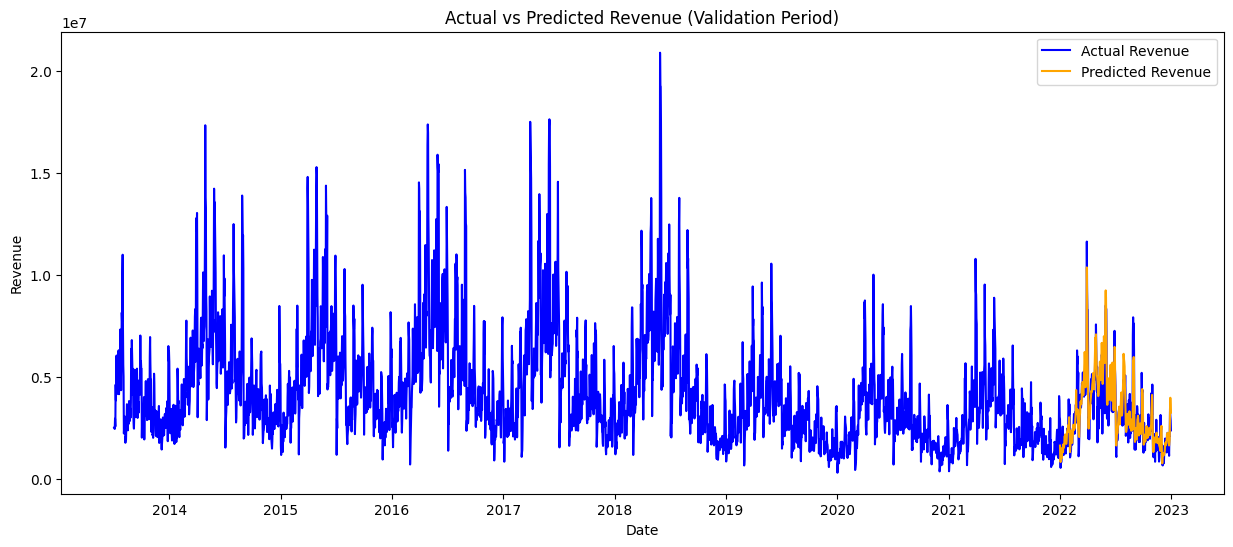

In [65]:
# plot
plt.figure(figsize=(15, 6))
plt.plot(data['Date'], data['Revenue'], label='Actual Revenue', color='blue')
plt.plot(comparison['Date'], comparison['Revenue_pred'], label='Predicted Revenue', color='orange')
plt.title('Actual vs Predicted Revenue (Validation Period)')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.show()

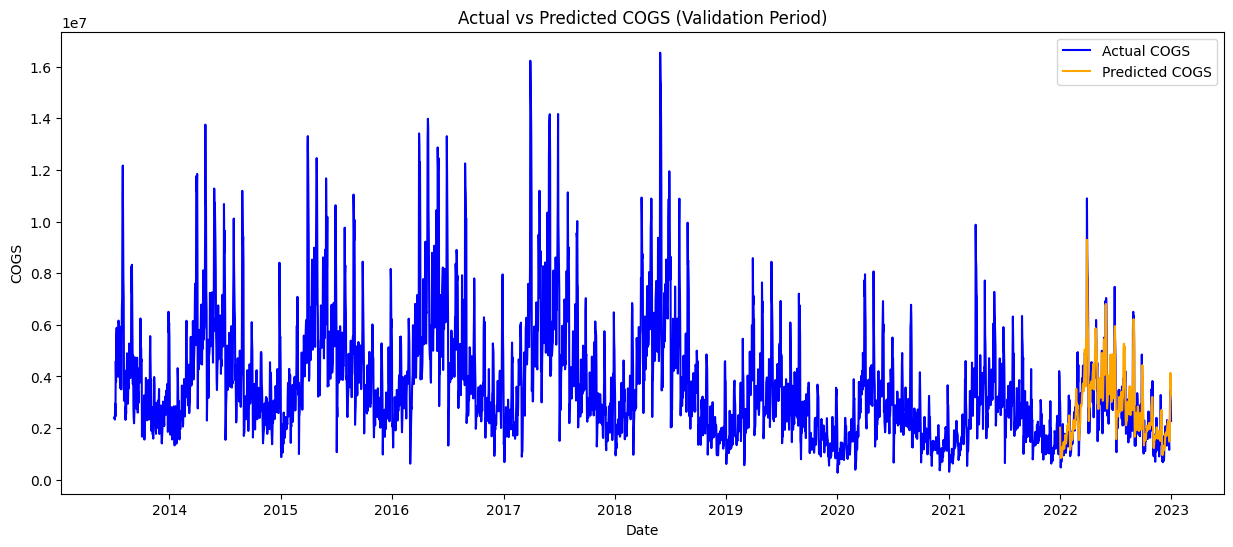

In [66]:
plt.figure(figsize=(15, 6))
plt.plot(data['Date'], data['COGS'], label='Actual COGS', color='blue')
plt.plot(comparison['Date'], comparison['COGS_pred'], label='Predicted COGS', color='orange')
plt.title('Actual vs Predicted COGS (Validation Period)')
plt.xlabel('Date')
plt.ylabel('COGS')
plt.legend()
plt.show()

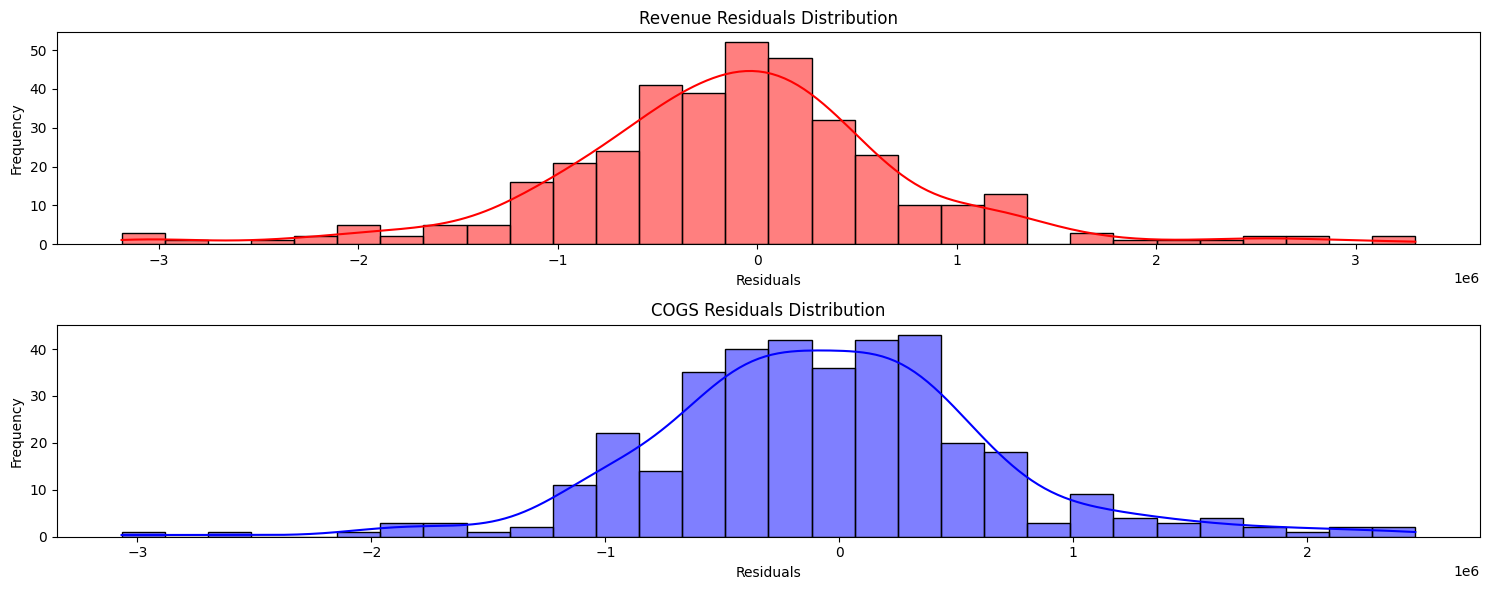

In [67]:
# residuals plot
comparison['Revenue_residual'] = comparison['Revenue_actual'] - comparison['Revenue_pred']
comparison['COGS_residual'] = comparison['COGS_actual'] - comparison['COGS_pred']
plt.figure(figsize=(15, 6))
plt.subplot(2, 1, 1)
sns.histplot(comparison['Revenue_residual'], bins=30, kde=True, color='red')
plt.title('Revenue Residuals Distribution')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

plt.subplot(2, 1, 2)
sns.histplot(comparison['COGS_residual'], bins=30, kde=True, color='blue')
plt.title('COGS Residuals Distribution')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()